# Findings 

- when an action leads to collide to the wall, it does nothing (stays in the same position before the action). 

- dot can be inside the wall 

- last state is discarded to match the action shape. 

In [1]:
import random
import sys
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

REPO_ROOT = Path.cwd().parents[1]          # examples/my_ac_video_jepa -> repo root
sys.path.insert(0, str(REPO_ROOT))

from eb_jepa.datasets.utils import init_data
from eb_jepa.datasets.two_rooms.utils import generate_wall_layouts

# torch.manual_seed(0); np.random.seed(0); random.seed(0)

### `load_env_data_config`

In [2]:
import yaml 

# load_env_data_config(env_name, overrides)
env_name  = "two_rooms"
overrides = {"batch_size": 128}
#====================================
DATASETS_DIR = Path("/Users/hawardizayee/Desktop/AMI/eb_jepa/eb_jepa/datasets")
config_path = DATASETS_DIR / env_name / "data_config.yaml"  # data_config.yaml is hardcoded 

print(config_path)

with open(config_path) as f:
    base_config = yaml.safe_load(f)

base_config.update(overrides)

base_config

/Users/hawardizayee/Desktop/AMI/eb_jepa/eb_jepa/datasets/two_rooms/data_config.yaml


{'action_noise': 1,
 'action_angle_noise': 0.2,
 'action_step_mean': 1.0,
 'action_step_std': 0.4,
 'action_lower_bd': 0.2,
 'action_upper_bd': 1.8,
 'dot_std': 1.3,
 'img_size': 65,
 'border_wall_loc': 5,
 'fix_wall_batch_k': None,
 'fix_wall': False,
 'fix_door_location': 18,
 'fix_wall_location': 32,
 'exclude_wall_train': '',
 'exclude_door_train': '',
 'only_wall_val': '',
 'only_door_val': '',
 'wall_padding': 20,
 'door_padding': 10,
 'wall_width': 3,
 'door_space': 4,
 'num_train_layouts': -1,
 'cross_wall_rate': 0.35,
 'expert_cross_wall_rate': 0,
 'wall_bump_rate': 0.0,
 'dup_traj_rate': 0.0,
 'max_step': 1,
 'sample_length': 17,
 'n_steps': 91,
 'n_steps_reduce_factor': 1,
 'repeat_actions': 1,
 'size': 100000,
 'val_size': 10000,
 'train': True,
 'normalize': True,
 'batch_size': 128,
 'num_workers': 0,
 'pin_mem': False,
 'persistent_workers': False,
 'device': 'cpu'}

### `update_config_from_yaml`

In [3]:
from dataclasses import fields
from eb_jepa.datasets.two_rooms.wall_dataset import WallDatasetConfig

In [4]:
config_class = WallDatasetConfig
fields(config_class)

(Field(name='size',type=<class 'int'>,default=10000,default_factory=<dataclasses._MISSING_TYPE object at 0x108b682c0>,init=True,repr=True,hash=None,compare=True,metadata=mappingproxy({}),kw_only=False,_field_type=_FIELD),
 Field(name='val_size',type=<class 'int'>,default=10000,default_factory=<dataclasses._MISSING_TYPE object at 0x108b682c0>,init=True,repr=True,hash=None,compare=True,metadata=mappingproxy({}),kw_only=False,_field_type=_FIELD),
 Field(name='batch_size',type=<class 'int'>,default=128,default_factory=<dataclasses._MISSING_TYPE object at 0x108b682c0>,init=True,repr=True,hash=None,compare=True,metadata=mappingproxy({}),kw_only=False,_field_type=_FIELD),
 Field(name='dot_std',type=<class 'float'>,default=1.3,default_factory=<dataclasses._MISSING_TYPE object at 0x108b682c0>,init=True,repr=True,hash=None,compare=True,metadata=mappingproxy({}),kw_only=False,_field_type=_FIELD),
 Field(name='action_noise',type=<class 'float'>,default=0.2,default_factory=<dataclasses._MISSING_TYP

In [5]:
config_field_names = {f.name for f in fields(config_class)}

relevant_yaml_data = {
    key: value for key, value in base_config.items() if key in config_field_names
}

In [6]:
config = config_class(**relevant_yaml_data)  # notice the batch_size has overridden 
config

WallDatasetConfig(size=100000, val_size=10000, batch_size=128, dot_std=1.3, action_noise=1, action_angle_noise=0.2, action_step_mean=1.0, action_step_std=0.4, action_lower_bd=0.2, action_upper_bd=1.8, max_step=1, n_steps=91, img_size=65, train=True, device='cpu', repeat_actions=1, n_steps_reduce_factor=1, border_wall_loc=5, chunked_actions=False, normalize=True, fix_wall=False, fix_wall_batch_k=None, wall_padding=20, door_padding=10, wall_width=3, door_space=4, cross_wall_rate=0.35, expert_cross_wall_rate=0, wall_bump_rate=0.0, dup_traj_rate=0.0, expert_action_step_mean=0.9, expert_action_step_std=0, expert_action_lower_bd=0.9, expert_action_upper_bd=0.9, expert_traj_door_padding=2, exclude_wall_train='', exclude_door_train='', only_wall_val='', only_door_val='', fix_wall_location=32, fix_door_location=18, num_train_layouts=-1, image_based=True, sample_length=17)

# WallDataset

In [7]:
from eb_jepa.datasets.two_rooms.wall_dataset import WallDataset

dset = WallDataset(config=config)
dset

In [8]:
# WallDataset generates a fresh random sample on every __getitem__ (the index is
# ignored), so re-seed right before sampling -> rerunning this cell always
# reproduces the same trajectory.
# SAMPLE_SEED = 0
# torch.manual_seed(SAMPLE_SEED); np.random.seed(SAMPLE_SEED); random.seed(SAMPLE_SEED)

sample = dset[0] # the data is generated on the fly, 
# the index is meaningless in context of different sample, 
# it only exists for DataLoader 

states, actions, locations, wall_x, door_y = sample

print(states.shape) # [C, T, H, W]
print(actions.shape)

# # this is what builds the states in dot channel. 
print(locations.shape)  

# There are logic for how thick is the wall size, and how large is the door in terms of pixels. (safely ignored)
print(wall_x.shape)
print(door_y.shape)


torch.Size([2, 17, 65, 65])
torch.Size([2, 17])
torch.Size([2, 17])
torch.Size([1])
torch.Size([1])


### locations 

- This is the normalized (x,y) where the dot trajectory is generated. 

In [9]:
locations 


tensor([[-0.5435, -0.5358, -0.4839, -0.4766, -0.4532, -0.4247, -0.3717, -0.2936,
         -0.2531, -0.1448, -0.0463,  0.0066,  0.0752,  0.1401,  0.2476,  0.3397,
          0.4130],
        [-0.5599, -0.5877, -0.6503, -0.6752, -0.7234, -0.7673, -0.8053, -0.7844,
         -0.7614, -0.7583, -0.7751, -0.7717, -0.7634, -0.7715, -0.7775, -0.7964,
         -0.8039]])

In [10]:
locations[:, 2] # (x,y) at timestep = 2  

tensor([-0.4839, -0.6503])

### actions 


- actions are not normalized, they stay in raw pixel. 

- What does the (x, y) mean? It's a displacement vector (Δx, Δy): "move Δx pixels horizontally and Δy pixels vertically this timestep.

- ‖(Δx, Δy)‖ ∈ [0.2, 1.8]

In [11]:
actions 

tensor([[ 0.1234,  0.8367,  0.1173,  0.3769,  0.4582,  0.8530,  1.2592,  0.6516,
          1.7431,  1.5874,  0.8512,  1.1046,  1.0452,  1.7306,  1.4834,  1.1798,
          0.9538],
        [-0.4498, -1.0098, -0.4022, -0.7773, -0.7080, -0.6132,  0.3372,  0.3710,
          0.0503, -0.2713,  0.0546,  0.1340, -0.1305, -0.0968, -0.3053, -0.1205,
          0.2771]])

###  wall_x and door_y

- the size of the door comes from the door space (which is 4 in the config)

In [12]:
print(wall_x)   # the vertical line in to create the wall 
print(door_y)   # the gap in y axis 

tensor([21])
tensor([18])


### States

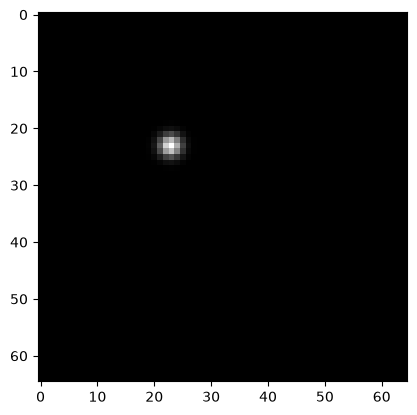

In [13]:
import matplotlib.pyplot as plt 

dot_channel = 0 
plt.imshow(states[dot_channel, 0],cmap="gray")

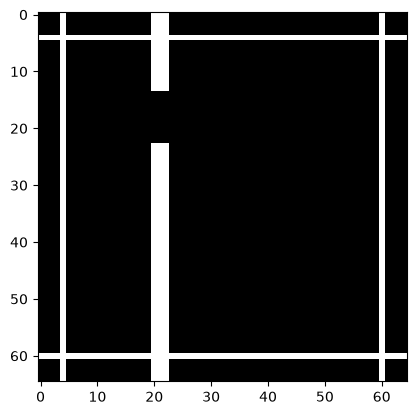

In [14]:
wall_channel = 1 
plt.imshow(states[wall_channel,0],cmap="gray")

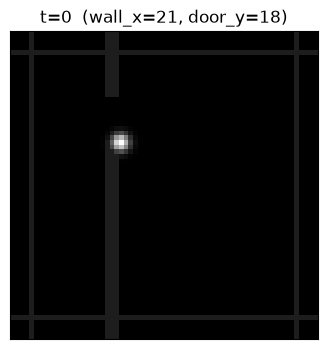

In [15]:
dot, wall = sample.states[0], sample.states[1]   # each [T, 65, 65]

t = 0  # pick any frame
frame = torch.maximum(dot[t], wall[t])

plt.figure(figsize=(4, 4))
plt.imshow(frame, cmap="gray")
plt.title(f"t={t}  (wall_x={sample.wall_x.item()}, door_y={sample.door_y.item()})")
plt.xticks([]); plt.yticks([])
plt.show()


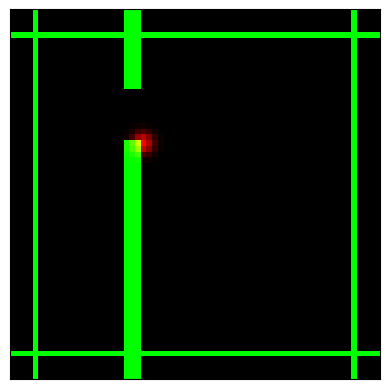

In [16]:
def to01(x):
    return (x - x.min()) / (x.max() - x.min())

rgb = torch.stack([to01(dot[t]), to01(wall[t]), torch.zeros_like(dot[t])], dim=-1)
plt.imshow(rgb)   # dot = red, wall = green
plt.xticks([]); plt.yticks([])
plt.show()


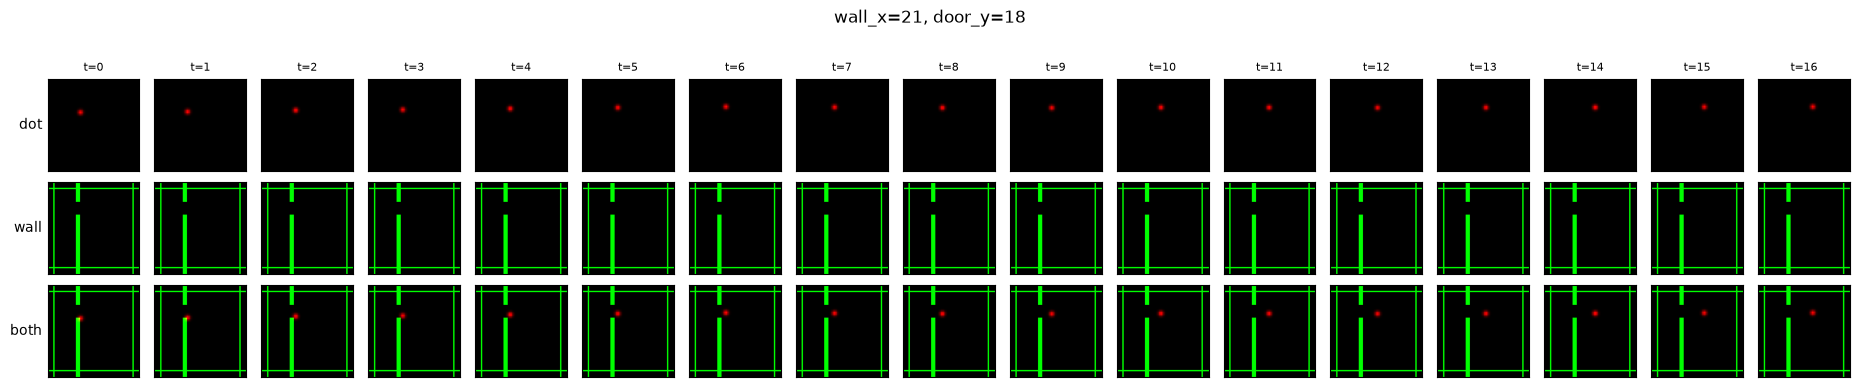

In [17]:
T = dot.shape[0]

def to01(x):
    return (x - x.min()) / (x.max() - x.min())

dot01, wall01 = to01(dot), to01(wall)            # normalize once, over the whole sequence
zeros = torch.zeros_like(dot01)

rows = [
    ("dot",  torch.stack([dot01,  zeros,  zeros], dim=-1)),   # red
    ("wall", torch.stack([zeros,  wall01, zeros], dim=-1)),   # green
    ("both", torch.stack([dot01,  wall01, zeros], dim=-1)),   # red + green
]

fig, axes = plt.subplots(3, T, figsize=(T * 1.1, 3.8))

for r, (name, frames) in enumerate(rows):        # frames: [T, 65, 65, 3]
    for t in range(T):
        ax = axes[r, t]
        ax.imshow(frames[t])
        ax.set_xticks([]); ax.set_yticks([])
        if r == 0:
            ax.set_title(f"t={t}", fontsize=8)
    axes[r, 0].set_ylabel(name, fontsize=10, rotation=0, ha="right", va="center")

fig.suptitle(f"wall_x={sample.wall_x.item()}, door_y={sample.door_y.item()}", y=1.02)
plt.tight_layout()
plt.show()


# `init_data`

In [18]:
from pathlib import Path 

CFG_PATH = Path.cwd().parent / "cfgs" / "train.yaml"

with open(CFG_PATH) as f:
    cfg = yaml.safe_load(f)

cfg["data"]["num_workers"] = 0 
cfg

{'logging': {'log_wandb': True,
  'wandb_group': None,
  'wandb_sweep': None,
  'log_every': 10,
  'exp_suffix': '26-07-20',
  'save_every_n_epochs': 1,
  'tqdm_silent': False},
 'meta': {'model_folder': None,
  'enable_plan_eval': True,
  'eval_every_itr': -1,
  'seed': 1},
 'data': {'env_name': 'two_rooms',
  'batch_size': 384,
  'num_workers': 0,
  'pin_mem': True,
  'persistent_workers': True},
 'training': {'use_amp': True, 'dtype': 'bfloat16'},
 'eval': {'plan_cfg_path': 'cfgs/planning_mppi.yaml'}}

In [19]:
from eb_jepa.datasets.utils import init_data

env_name = "two_rooms"


loader, val_loader, data_config = init_data(env_name= env_name, cfg_data=dict(cfg["data"]))

In [20]:
data_config

WallDatasetConfig(size=100000, val_size=10000, batch_size=384, dot_std=1.3, action_noise=1, action_angle_noise=0.2, action_step_mean=1.0, action_step_std=0.4, action_lower_bd=0.2, action_upper_bd=1.8, max_step=1, n_steps=91, img_size=65, train=True, device='cpu', repeat_actions=1, n_steps_reduce_factor=1, border_wall_loc=5, chunked_actions=False, normalize=True, fix_wall=False, fix_wall_batch_k=None, wall_padding=20, door_padding=10, wall_width=3, door_space=4, cross_wall_rate=0.35, expert_cross_wall_rate=0, wall_bump_rate=0.0, dup_traj_rate=0.0, expert_action_step_mean=0.9, expert_action_step_std=0, expert_action_lower_bd=0.9, expert_action_upper_bd=0.9, expert_traj_door_padding=2, exclude_wall_train='', exclude_door_train='', only_wall_val='', only_door_val='', fix_wall_location=32, fix_door_location=18, num_train_layouts=-1, image_based=True, sample_length=17)

In [26]:
print(data_config.batch_size)
print(data_config.size) # train samples  
print(data_config.val_size)

steps_per_epoch = data_config.size // data_config.batch_size
print(steps_per_epoch)

print(data_config.img_size)

384
100000
10000
260
65


In [21]:
batch = next(iter(loader))
batch

WallSample(states=tensor([[[[[-0.0705, -0.0705, -0.0705,  ..., -0.0705, -0.0705, -0.0705],
           [-0.0705, -0.0705, -0.0705,  ..., -0.0705, -0.0705, -0.0705],
           [-0.0705, -0.0705, -0.0705,  ..., -0.0705, -0.0705, -0.0705],
           ...,
           [-0.0705, -0.0705, -0.0705,  ..., -0.0705, -0.0705, -0.0705],
           [-0.0705, -0.0705, -0.0705,  ..., -0.0705, -0.0705, -0.0705],
           [-0.0705, -0.0705, -0.0705,  ..., -0.0705, -0.0705, -0.0705]],

          [[-0.0705, -0.0705, -0.0705,  ..., -0.0705, -0.0705, -0.0705],
           [-0.0705, -0.0705, -0.0705,  ..., -0.0705, -0.0705, -0.0705],
           [-0.0705, -0.0705, -0.0705,  ..., -0.0705, -0.0705, -0.0705],
           ...,
           [-0.0705, -0.0705, -0.0705,  ..., -0.0705, -0.0705, -0.0705],
           [-0.0705, -0.0705, -0.0705,  ..., -0.0705, -0.0705, -0.0705],
           [-0.0705, -0.0705, -0.0705,  ..., -0.0705, -0.0705, -0.0705]],

          [[-0.0705, -0.0705, -0.0705,  ..., -0.0705, -0.0705, -0.0705

In [22]:
states, actions, loc, wall_x, door_y = batch 
print(states.shape)
print(actions.shape)
print(loc.shape)
print(wall_x.shape)
print(door_y.shape)

torch.Size([384, 2, 17, 65, 65])
torch.Size([384, 2, 17])
torch.Size([384, 2, 17])
torch.Size([384, 1])
torch.Size([384, 1])
